# Acceso a API y Obtención de Datos Climáticos
Dado que se quiere realizar una proyección de los valores de DALYs en función de su correlación con las variables socioeconómicas y ambientales. De esta manera, se accederá a la API de Climate Impact Explorer (https://climate-impact-explorer.climateanalytics.org/) para tener datos disponibles sobre impactos climáticos y su severidad a través de varios países bajo varios escenarios de cambio global. 

## Descarga de Datos por API de CIE
Se eligieron los 10 países con mayor y menor carga de DALYs para hacer dichas extrapolaciones. 
- Top 10 países: ['Nigeria', 'India', 'Niger', 'Mozambique', 'China', 'Uganda', 'Ethiopia', 'Mali', 'Burkina Faso', 'Cameroon']
- Bottom 10 países (con DALYs > 0): ['Iceland', 'Luxembourg', 'Finland', 'Bahrain', 'Denmark', 'Grenada', 'Cyprus', 'Ireland', 'Belgium', 'Qatar']


In [1]:
# Configuración de librerías. 

import pandas as pd
import numpy as np
from joblib import load
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from joblib import dump
import matplotlib.pyplot as plt

In [2]:
in_file = "data_clean/DALYs_clean_unificado_NEW.pkl"
with open(in_file, 'rb') as f:
     df_dalys= load(f)
display(df_dalys)
print(df_dalys.columns.tolist())

df_clima = pd.read_csv('data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv')

,ano,pais,codigo_pais,codigo_ghe,categoria_principal,categoria_nivel1,categoria_nivel2,causa,sexo,edad,...,esperanza_vida,poblacion_miles,co2_anual,precipitacion_total,temperatura_superficial,humedad_relativa,poblacion_abs,tasa_dalys_100k,dalys_por_intervencion,desarrollo_vs_carga
0,2000,Afghanistan,AFG,210.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,NaN,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,1700.371055,1.700418e-02,NaN
1,2000,Afghanistan,AFG,220.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,a.Malaria,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,574.705573,5.747520e-03,NaN
2,2000,Afghanistan,AFG,230.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,b.Trypanosomiasis,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000,4.645592e-07,NaN
3,2000,Afghanistan,AFG,240.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,c.Chagas disease,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000,4.645592e-07,NaN
4,2000,Afghanistan,AFG,250.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,9.Parasitic and vector diseases,d.Schistosomiasis,Males,0-4,...,53.76,2152.578,511.1,0.009,9.687,40.39,2152578.0,0.000000,4.645592e-07,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310795,2021,Zimbabwe,ZWE,340.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,a.Ascariasis,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,2.124487,2.642214e-05,1.142974e+00
310796,2021,Zimbabwe,ZWE,350.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,b.Trichuriasis,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,0.000002,5.177285e-06,8.345278e-07
310797,2021,Zimbabwe,ZWE,360.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,c.Hookworm disease,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,63.569558,6.408728e-04,3.420042e+01
310798,2021,Zimbabwe,ZWE,362.0,"I.Communicable, maternal, perinatal and nutrit...",A.Infectious and parasitic diseases,10.Intestinal nematode infections,d.Food-borne trematodes,Females,70+,...,62.05,193.152,26239.0,0.026,21.090,57.65,193152.0,0.000000,5.177270e-06,0.000000e+00


['ano', 'pais', 'codigo_pais', 'codigo_ghe', 'categoria_principal', 'categoria_nivel1', 'categoria_nivel2', 'causa', 'sexo', 'edad', 'dalys', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'poblacion_abs', 'tasa_dalys_100k', 'dalys_por_intervencion', 'desarrollo_vs_carga']


In [ ]:
# Acceso a datos

## Configuración de consulta ##

# Países seleccionados
PAIS = [
    # África (alta carga de NTDs)
    "NGA",  # Nigeria
    "COD",  # Congo Democrático
    "ETH",  # Etiopía
    "TZA",  # Tanzania
    "UGA",  # Uganda
    "KEN",  # Kenia
    "MOZ",  # Mozambique
    "MWI",  # Malawi
    "ZMB",  # Zambia
    "CMR",  # Camerún
    "NER",  # Níger
    "MLI",  # Malí
    "BFA",  # Burkina Faso
    "SEN",  # Senegal
    "GHA",  # Ghana
    
    # Asia
    "IND",  # India
    "BGD",  # Bangladesh
    "PAK",  # Pakistán
    "MMR",  # Myanmar
    "IDN",  # Indonesia
    "CHN",  # China
    
    # América Latina
    "BRA",  # Brasil
    "MEX",  # México
    "COL",  # Colombia
    "PER",  # Perú
    
    # Referencia (baja carga)
    "ISL",  # Islandia
    "LUX",  # Luxemburgo
    "FIN",  # Finlandia
    "BHR",  # Baréin
    "DNK",  # Dinamarca
    "GRD",  # Granada
    "CYP",  # Chipre
    "IRL",  # Irlanda
    "BEL",  # Bélgica
    "QAT"   # Catar
]

# Variables climáticas
VARIABLE = [
    "tasAdjust",    # Temperatura media
    "prAdjust",     # Precipitación
    "hursAdjust",   # Humedad relativa
    "tasmaxAdjust", # Temperatura diaria máxima
    "tasminAdjust"  # Temperatura diaria mínima
]
# Escenario de emisiones (usaremos el de altas emisiones 'h_cpol' y el de mitigación 'o_1p5c')
ESCENARIO = ["h_cpol" , "o_1p5c"] 

BASE_URL = "https://cie-api-v2.climateanalytics.org/api/timeseries/"

# --- Función de descarga (CORREGIDA) ---
def descargar_datos(pais, variable, escenario):
    """
    Descarga los datos de la API para una combinación específica.
    Retorna un DataFrame con los datos o None si hay error.
    """
    
    # Parámetros de la consulta
    params = {
        "iso": pais,
        "region": pais,
        "scenario": escenario,
        "var": variable,
        "aggregation_spatial": "area",
        "season": "annual",
        "format": "json"
    }
    
    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        datos = response.json()
        
        if 'status' in datos:
            return None
            
        df = pd.DataFrame({
            'year': datos['year'],
            'value': datos['median'],
            'value_lower': datos['lower'],
            'value_upper': datos['upper'],
            'warming_level': datos['warming_levels']
        })
        
        df['pais'] = pais
        df['variable'] = variable
        df['escenario'] = escenario
        
        return df
        
    except:
        return None

# --- Descarga masiva ---
print(f"Descargando {len(PAIS) * len(VARIABLE) * len(ESCENARIO)} combinaciones...")

todos = []
for pais in tqdm(PAIS):
    for var in VARIABLE:
        for esc in ESCENARIO:
            df = descargar_datos(pais, var, esc)
            if df is not None:
                todos.append(df)
            time.sleep(0.1)

# --- Guardar resultados ---
if todos:
    df_final = pd.concat(todos, ignore_index=True)
    
    # Reordenar columnas para formato tidy estándar
    columnas_orden = ['year', 'pais', 'escenario', 'variable', 'value', 'value_lower', 'value_upper', 'warming_level']
    df_final = df_final[columnas_orden]
    df_final = df_final.sort_values(['pais', 'escenario', 'variable', 'year'])
    
    df_final.to_csv('data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv', index=False)
    
    print(f"\n Completado! {len(df_final)} registros guardados en 'data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv'")
    print(df_final.head(10))
    
    # Mostrar resumen
    print("\n Resumen por variable:")
    print(df_final.groupby('variable').size())
else:
    print("No se descargaron datos. Verifica tu conexión a internet.")

Descargando 350 combinaciones...


100%|██████████| 35/35 [03:50<00:00,  6.57s/it]


 Completado! 6300 registros guardados en 'data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv'
        year pais escenario    variable      value  value_lower  value_upper  \
6012  2015.0  BEL    h_cpol  hursAdjust  80.654830    79.835887    81.305855   
6013  2020.0  BEL    h_cpol  hursAdjust  80.568827    79.682841    81.410657   
6014  2025.0  BEL    h_cpol  hursAdjust  80.446939    79.339350    81.398392   
6015  2030.0  BEL    h_cpol  hursAdjust  80.292301    79.095014    81.370471   
6016  2035.0  BEL    h_cpol  hursAdjust  80.158094    78.996112    81.335199   
6017  2040.0  BEL    h_cpol  hursAdjust  80.048425    78.826478    81.327597   
6018  2045.0  BEL    h_cpol  hursAdjust  79.961415    78.551974    81.330905   
6019  2050.0  BEL    h_cpol  hursAdjust  79.884367    78.348219    81.356348   
6020  2055.0  BEL    h_cpol  hursAdjust  79.842134    78.207203    81.384475   
6021  2060.0  BEL    h_cpol  hursAdjust  79.807045    78.121132    81.418485   

      warm

In [16]:
# ============================================
# Filtrar años comunes (2015 y 2020)
# ============================================
df_dalys_common = df_dalys[df_dalys['ano'].isin([2015, 2020])].copy()
df_clima_common = df_clima[df_clima['year'].isin([2015, 2020])].copy()

print(f"\n DALYS años comunes: {df_dalys_common.shape}")
print(f" Clima años comunes: {df_clima_common.shape}")

# ============================================
# Transformar datos climáticos a formato wide
# ============================================
df_clima_wide = df_clima_common.pivot_table(
    index=['year', 'pais', 'escenario'],
    columns='variable',
    values='value'
).reset_index()

print(f" Columnas en df_clima_wide: {df_clima_wide.columns.tolist()}")

# ============================================
# Limpieza df_dalys_renamed
# ============================================

df_dalys_renamed = (df_dalys_common
    .drop(columns=['pais'])  # Eliminar nombre completo del país
    .rename(columns={
        'codigo_pais': 'pais',  # Renombrar código ISO a 'pais'
        'ano': 'year',
        'tasa_dalys_100k': 'dalys'
    })
)

print(f" Columnas en df_dalys_renamed: {df_dalys_renamed.columns.tolist()}")
print(f"Códigos ISO en DALYS: {df_dalys_renamed['pais'].unique()[:10]}")

# ============================================
# Verificar que los tipos coinciden
# ============================================
df_clima_wide['pais'] = df_clima_wide['pais'].astype(str).str.strip().str.upper()
df_dalys_renamed['pais'] = df_dalys_renamed['pais'].astype(str).str.strip().str.upper()
df_clima_wide['year'] = df_clima_wide['year'].astype(int)
df_dalys_renamed['year'] = df_dalys_renamed['year'].astype(int)

# ============================================
# Verificar años y países comunes
# ============================================
print(f"\n Años en clima: {sorted(df_clima_wide['year'].unique())}")
print(f" Años en DALYS: {sorted(df_dalys_renamed['year'].unique())}")

paises_clima = set(df_clima_wide['pais'].unique())
paises_dalys = set(df_dalys_renamed['pais'].unique())
paises_comunes = paises_clima & paises_dalys

print(f" Países en clima: {len(paises_clima)}")
print(f" Países en DALYS: {len(paises_dalys)}")
print(f" Países en común: {len(paises_comunes)}")

if paises_comunes:
    print(f"Ejemplo de países comunes: {list(paises_comunes)[:5]}")
else:
    print("\nNo hay países en común. Ejemplos:")
    print(f"  Clima: {list(paises_clima)[:5]}")
    print(f"  DALYS: {list(paises_dalys)[:5]}")

# ============================================
# Merge de los datos para entrenamiento
# ============================================
if paises_comunes:
    df_merged = df_clima_wide.merge(
        df_dalys_renamed[['year', 'pais', 'dalys']],
        on=['year', 'pais'],
        how='inner'
    )
    
    print(f"\n Datos combinados para entrenamiento: {df_merged.shape}")
    print(f"Filas: {len(df_merged)}")
    print(f"Años incluidos: {df_merged['year'].unique()}")
    print(f"Países incluidos: {df_merged['pais'].nunique()}")
    
    if len(df_merged) > 0:
        print(df_merged[['year', 'pais', 'escenario', 'dalys', 'tasAdjust']].head(10))


 DALYS años comunes: (83580, 26)
 Clima años comunes: (700, 8)
 Columnas en df_clima_wide: ['year', 'pais', 'escenario', 'hursAdjust', 'prAdjust', 'tasAdjust', 'tasmaxAdjust', 'tasminAdjust']
 Columnas en df_dalys_renamed: ['year', 'pais', 'codigo_ghe', 'categoria_principal', 'categoria_nivel1', 'categoria_nivel2', 'causa', 'sexo', 'edad', 'dalys', 'pib_per_capita', 'idh', 'indice_educacion', 'indice_salud', 'indice_ingresos', 'esperanza_vida', 'poblacion_miles', 'co2_anual', 'precipitacion_total', 'temperatura_superficial', 'humedad_relativa', 'poblacion_abs', 'dalys', 'dalys_por_intervencion', 'desarrollo_vs_carga']
Códigos ISO en DALYS: ['AFG', 'ALB', 'DZA', 'AGO', 'ARM', 'AUS', 'AUT', 'AZE', 'BHR', 'BGD']
Categories (185, object): ['AFG', 'AGO', 'ALB', 'ARE', ..., 'YEM', 'ZAF', 'ZMB', 'ZWE']

 Años en clima: [np.int64(2015), np.int64(2020)]
 Años en DALYS: [np.int64(2015), np.int64(2020)]
 Países en clima: 35
 Países en DALYS: 155
 Países en común: 33
Ejemplo de países comunes: ['

## Entrenamiento con años comunes entre los DataFrames
Se entrenará un modelo lineal con los años de 2015 y 2020. Para ello se van a concatenar el DataFrame de DALYs y el de datos climáticos dados por la API.

DIAGNÓSTICO DE DATOS
Shape original de df_merged: (35840, 9)
Columnas: ['year', 'pais', 'escenario', 'hursAdjust', 'prAdjust', 'tasAdjust', 'tasmaxAdjust', 'tasminAdjust', 'dalys']

LIMPIANDO COLUMNAS DUPLICADAS
Shape después de eliminar duplicados: (35840, 9)
Columnas únicas: ['year', 'pais', 'escenario', 'hursAdjust', 'prAdjust', 'tasAdjust', 'tasmaxAdjust', 'tasminAdjust', 'dalys']
 Columna 'dalys' encontrada
  Valores nulos en dalys: 0
  Rango de dalys: [0.00e+00, 8.69e+06]

 Features disponibles: ['tasAdjust', 'prAdjust', 'hursAdjust', 'tasmaxAdjust', 'tasminAdjust']

Shape antes de limpiar nulos: (35840, 9)
Columnas a verificar: ['tasAdjust', 'prAdjust', 'hursAdjust', 'tasmaxAdjust', 'tasminAdjust', 'dalys']
Shape después de eliminar nulos: (35840, 6)
Shape final de X_train: (35840, 5)
Shape final de y_train: (35840,)
✓ Dimensiones correctas

 Estadísticas del dataset:
  Total de muestras: 35840
  Características: 5
  DALYs - Media: 9872.38
  DALYs - Std: 176714.60

 Resultados d

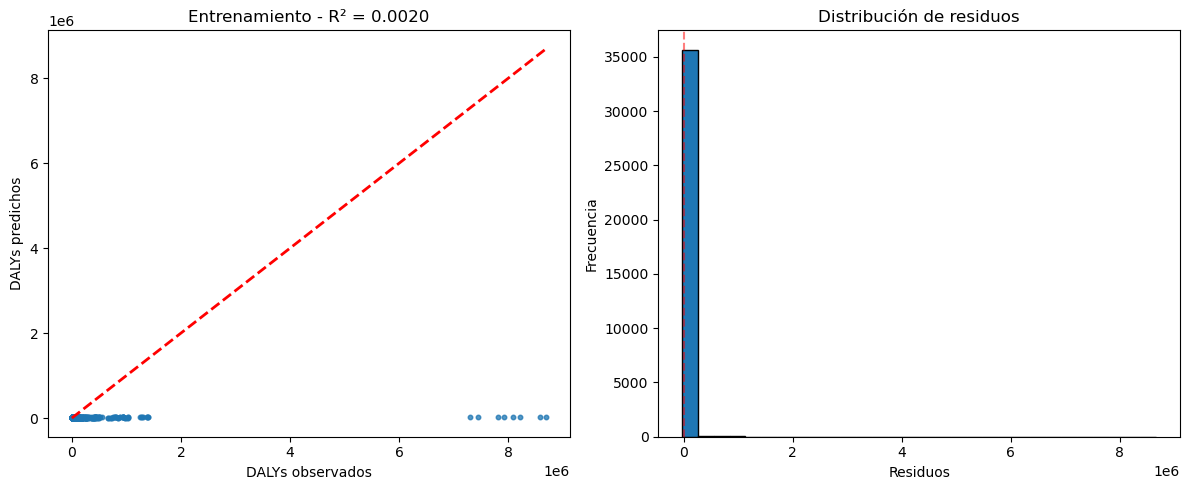


 Datos climáticos completos: (6300, 8)
Años disponibles: [np.float64(2015.0), np.float64(2020.0), np.float64(2025.0), np.float64(2030.0), np.float64(2035.0), np.float64(2040.0), np.float64(2045.0), np.float64(2050.0), np.float64(2055.0), np.float64(2060.0), np.float64(2065.0), np.float64(2070.0), np.float64(2075.0), np.float64(2080.0), np.float64(2085.0), np.float64(2090.0), np.float64(2095.0), np.float64(2100.0)]
 Años futuros a predecir: [np.float64(2025.0), np.float64(2030.0), np.float64(2035.0), np.float64(2040.0), np.float64(2045.0), np.float64(2050.0), np.float64(2055.0), np.float64(2060.0), np.float64(2065.0), np.float64(2070.0), np.float64(2075.0), np.float64(2080.0), np.float64(2085.0), np.float64(2090.0), np.float64(2095.0), np.float64(2100.0)]

Shape de datos futuros (wide): (1120, 8)
Primeras 5 columnas: ['year', 'pais', 'escenario', 'hursAdjust', 'prAdjust']
Features a usar para predicción: ['tasAdjust', 'prAdjust', 'hursAdjust', 'tasmaxAdjust', 'tasminAdjust']
Shape de X

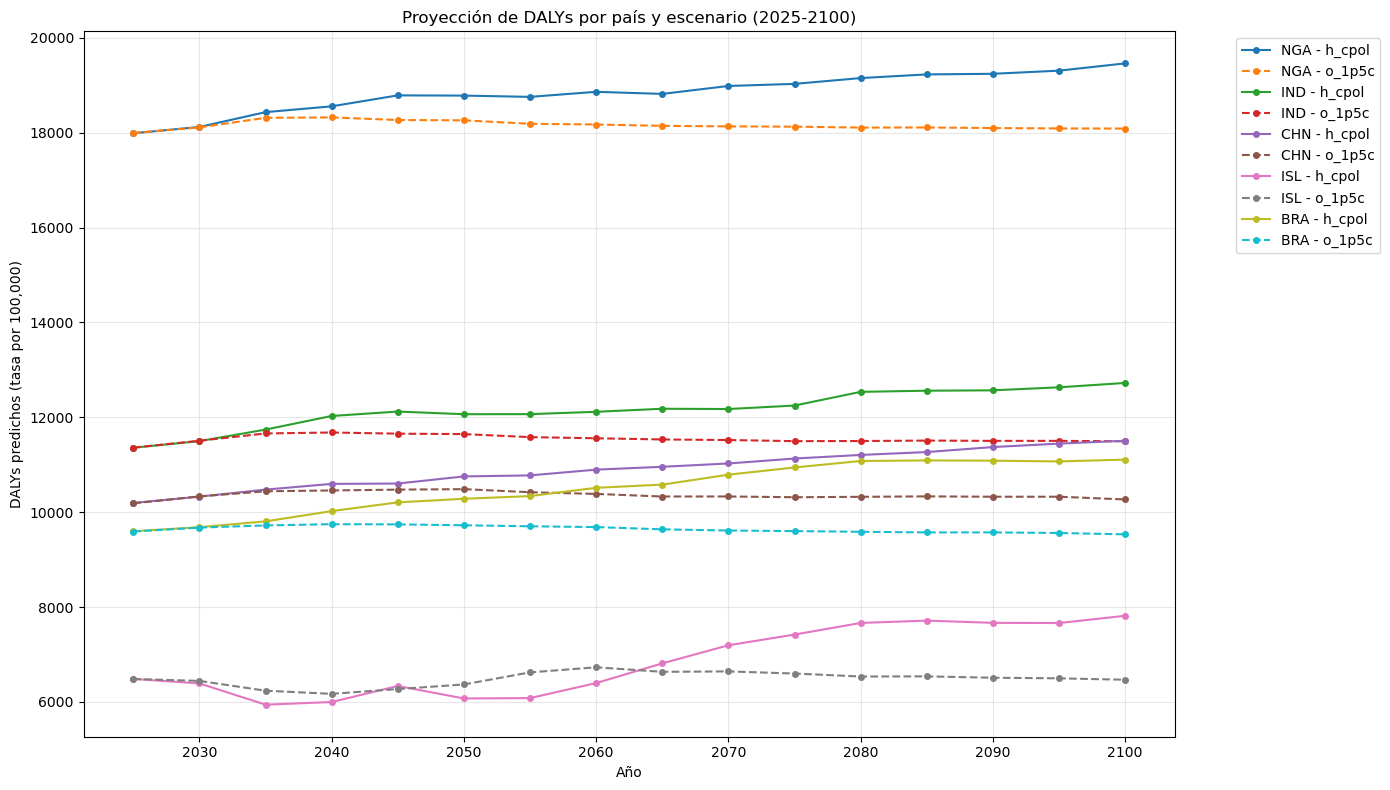


 Resumen de predicciones por escenario:

h_cpol:
  Media: 10421.78
  Mediana: 9943.17
  Std: 7715.21
  Min: -4632.73
  Max: 31605.96

o_1p5c:
  Media: 9875.00
  Mediana: 9449.70
  Std: 7669.78
  Min: -4644.51
  Max: 30649.81


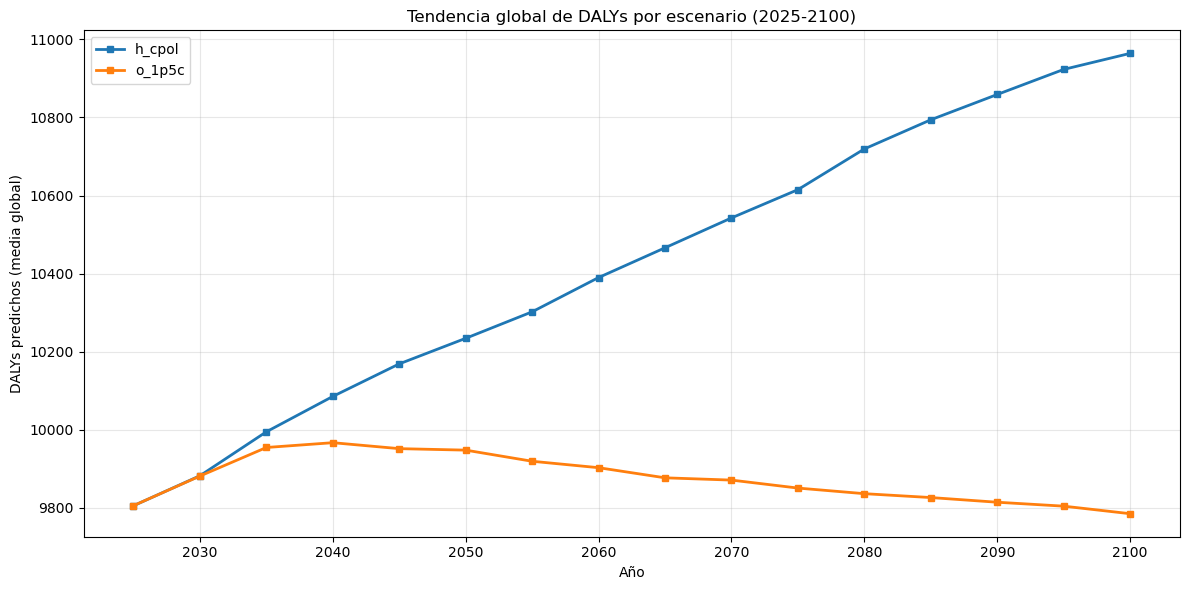


 Top 5 países con mayor DALYs promedio (escenario h_cpol, 2100):
  NER: 31415.56
  MLI: 30387.98
  BFA: 21354.16
  NGA: 19461.02
  SEN: 18165.39


In [20]:
# ============================================
# Diagnóstico y limpieza de datos
# ============================================
print("=" * 50)
print("DIAGNÓSTICO DE DATOS")
print("=" * 50)

# Mostrar información básica
print(f"Shape original de df_merged: {df_merged.shape}")
print(f"Columnas: {df_merged.columns.tolist()}")

# ============================================
# Limpiar columnas duplicadas
# ============================================
print("\n" + "=" * 50)
print("LIMPIANDO COLUMNAS DUPLICADAS")
print("=" * 50)

# Eliminar columnas duplicadas (conservar la primera)
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]
print(f"Shape después de eliminar duplicados: {df_merged.shape}")
print(f"Columnas únicas: {df_merged.columns.tolist()}")

# Verificar si 'dalys' está duplicada en los datos originales
if 'dalys' in df_merged.columns:
    print(f" Columna 'dalys' encontrada")
    # Verificar valores nulos en dalys
    print(f"  Valores nulos en dalys: {df_merged['dalys'].isnull().sum()}")
    print(f"  Rango de dalys: [{df_merged['dalys'].min():.2e}, {df_merged['dalys'].max():.2e}]")

# ============================================
# Separar features y target
# ============================================
features = ['tasAdjust', 'prAdjust', 'hursAdjust', 'tasmaxAdjust', 'tasminAdjust']
available_features = [f for f in features if f in df_merged.columns]
print(f"\n Features disponibles: {available_features}")

# Verificar y eliminar filas con valores nulos en features o target
print(f"\nShape antes de limpiar nulos: {df_merged.shape}")

# Asegurarse de que todas las columnas existen
columns_to_check = available_features + ['dalys']
existing_columns = [col for col in columns_to_check if col in df_merged.columns]
print(f"Columnas a verificar: {existing_columns}")

df_clean = df_merged[existing_columns].dropna()
print(f"Shape después de eliminar nulos: {df_clean.shape}")

# Extraer features y target
X_train = df_clean[available_features]
y_train = df_clean['dalys'].values.ravel()  # ravel asegura 1D

print(f"Shape final de X_train: {X_train.shape}")
print(f"Shape final de y_train: {y_train.shape}")

if X_train.shape[0] != y_train.shape[0]:
    raise ValueError(f"Dimensiones no coinciden: X={X_train.shape[0]}, y={y_train.shape[0]}")

print(f"✓ Dimensiones correctas")

# ============================================
# Verificar si hay suficientes datos
# ============================================
print(f"\n Estadísticas del dataset:")
print(f"  Total de muestras: {len(X_train)}")
print(f"  Características: {X_train.shape[1]}")
print(f"  DALYs - Media: {y_train.mean():.2f}")
print(f"  DALYs - Std: {y_train.std():.2f}")

# ============================================
# Escalar y entrenar modelo
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluación
y_pred_train = model.predict(X_train_scaled)
r2 = r2_score(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Extract intercept value correctly
intercept_value = model.intercept_[0] if isinstance(model.intercept_, np.ndarray) else model.intercept_

print(f"\n Resultados del modelo:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  Intercepto: {intercept_value:.2f}")
print(f"\n  Coeficientes:")
for feat, coef in zip(available_features, model.coef_):
    coef_value = coef[0] if isinstance(coef, np.ndarray) else coef
    print(f"    {feat}: {coef_value:.4f}")

# ============================================
# Guardar modelo y scaler
# ============================================
dump(model, 'data_clean/linear_model_daly_prediction/modelo_dalys.joblib')
dump(scaler, 'data_clean/linear_model_daly_prediction/scaler_dalys.joblib')
print("\n✅ Modelo y scaler guardados")

# ============================================
# Visualización
# ============================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('DALYs observados')
plt.ylabel('DALYs predichos')
plt.title(f'Entrenamiento - R² = {r2:.4f}')

plt.subplot(1, 2, 2)
residuos = y_train - y_pred_train
plt.hist(residuos, bins=30, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de residuos')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data_clean/linear_model_daly_prediction/modelo_dalys_evaluacion.png', dpi=150)
plt.show()

# ============================================
# Predicciones para años futuros (2025-2100)
# ============================================
# Cargar datos climáticos completos (todos los años)
try:
    df_clima_completo = pd.read_csv('data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv')
    print(f"\n Datos climáticos completos: {df_clima_completo.shape}")
    print(f"Años disponibles: {sorted(df_clima_completo['year'].unique())}")
except FileNotFoundError:
    print("Archivo 'datos_climaticos_CIE.csv' no encontrado. Usando 'data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv'")
    df_clima_completo = pd.read_csv('data_clean/linear_model_daly_prediction/datos_climaticos_CIE.csv')
    print(f"\n Datos climáticos completos: {df_clima_completo.shape}")
    print(f"Años disponibles: {sorted(df_clima_completo['year'].unique())}")

# Filtrar años futuros (>= 2025)
df_futuro = df_clima_completo[df_clima_completo['year'] >= 2025].copy()
print(f" Años futuros a predecir: {sorted(df_futuro['year'].unique())}")

# Transformar a formato wide
df_futuro_wide = df_futuro.pivot_table(
    index=['year', 'pais', 'escenario'],
    columns='variable',
    values='value'
).reset_index()

print(f"\nShape de datos futuros (wide): {df_futuro_wide.shape}")
print(f"Primeras 5 columnas: {df_futuro_wide.columns.tolist()[:5]}")

# Verificar features disponibles
missing_features = [f for f in available_features if f not in df_futuro_wide.columns]
if missing_features:
    print(f"Features faltantes en datos futuros: {missing_features}")
    available_features_future = [f for f in available_features if f in df_futuro_wide.columns]
else:
    available_features_future = available_features

print(f"Features a usar para predicción: {available_features_future}")

# Predecir
if len(available_features_future) > 0:
    X_future = df_futuro_wide[available_features_future].copy()
    print(f"Shape de X_future: {X_future.shape}")
    
    # Verificar y manejar valores nulos
    print(f"Valores nulos en X_future: {X_future.isnull().sum().sum()}")
    if X_future.isnull().any().any():
        print(" Eliminando filas con valores nulos...")
        valid_rows = ~X_future.isnull().any(axis=1)
        X_future = X_future[valid_rows]
        df_futuro_wide = df_futuro_wide[valid_rows].copy()
        print(f"Nuevo shape después de limpiar nulos: {X_future.shape}")
    
    # Escalar y predecir
    X_future_scaled = scaler.transform(X_future)
    predictions = model.predict(X_future_scaled)
    df_futuro_wide.loc[:, 'dalys_predicho'] = predictions.ravel() if hasattr(predictions, 'ravel') else predictions
    
    # ============================================
    # Resultados de predicciones
    # ============================================
    print(f"\n Predicciones realizadas: {len(df_futuro_wide)}")
    print("\nPrimeras predicciones:")
    display_cols = ['year', 'pais', 'escenario', 'dalys_predicho']
    if available_features_future:
        display_cols.append(available_features_future[0])
    print(df_futuro_wide[display_cols].head(10))
    
    # ============================================
    # Guardar predicciones
    # ============================================
    df_futuro_wide.to_csv('data_clean/linear_model_daly_prediction/predicciones_dalys_2025_2100.csv', index=False)
    print("\n Predicciones guardadas en 'data_clean/linear_model_daly_prediction/predicciones_dalys_2025_2100.csv'")
    
    # ============================================
    # Visualizar predicciones
    # ============================================
    paises_mostrar = ['NGA', 'IND', 'CHN', 'ISL', 'USA', 'BRA']
    paises_disponibles = df_futuro_wide['pais'].unique()
    paises_mostrar = [p for p in paises_mostrar if p in paises_disponibles]
    
    if paises_mostrar:
        df_plot = df_futuro_wide[df_futuro_wide['pais'].isin(paises_mostrar)]
        
        plt.figure(figsize=(14, 8))
        for pais in paises_mostrar:
            for escenario in ['h_cpol', 'o_1p5c']:
                if escenario in df_plot['escenario'].unique():
                    subset = df_plot[(df_plot['pais'] == pais) & (df_plot['escenario'] == escenario)]
                    if not subset.empty:
                        label = f"{pais} - {escenario}"
                        linestyle = '-' if escenario == 'h_cpol' else '--'
                        plt.plot(subset['year'], subset['dalys_predicho'], 
                                label=label, linestyle=linestyle, marker='o', markersize=4)
        
        plt.xlabel('Año')
        plt.ylabel('DALYs predichos (tasa por 100,000)')
        plt.title('Proyección de DALYs por país y escenario (2025-2100)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('data_clean/linear_model_daly_prediction/predicciones_dalys_por_pais.png', dpi=150)
        plt.show()
    else:
        print(f"\n No se encontraron países seleccionados. Países disponibles: {paises_disponibles[:10]}")
    
    # ============================================
    # Resumen estadístico
    # ============================================
    print("\n Resumen de predicciones por escenario:")
    for escenario in df_futuro_wide['escenario'].unique():
        subset = df_futuro_wide[df_futuro_wide['escenario'] == escenario]
        print(f"\n{escenario}:")
        print(f"  Media: {subset['dalys_predicho'].mean():.2f}")
        print(f"  Mediana: {subset['dalys_predicho'].median():.2f}")
        print(f"  Std: {subset['dalys_predicho'].std():.2f}")
        print(f"  Min: {subset['dalys_predicho'].min():.2f}")
        print(f"  Max: {subset['dalys_predicho'].max():.2f}")
    
    # ============================================
    # Tendencia global
    # ============================================
    plt.figure(figsize=(12, 6))
    for escenario in df_futuro_wide['escenario'].unique():
        yearly_mean = df_futuro_wide[df_futuro_wide['escenario'] == escenario].groupby('year')['dalys_predicho'].mean()
        plt.plot(yearly_mean.index, yearly_mean.values, 
                label=escenario, marker='s', markersize=4, linewidth=2)
    
    plt.xlabel('Año')
    plt.ylabel('DALYs predichos (media global)')
    plt.title('Tendencia global de DALYs por escenario (2025-2100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('data_clean/linear_model_daly_prediction/tendencia_global_dalys.png', dpi=150)
    plt.show()
    
    # ============================================
    # Análisis adicional: Distribución por país
    # ============================================
    print("\n Top 5 países con mayor DALYs promedio (escenario h_cpol, 2100):")
    year_2100_hcpol = df_futuro_wide[(df_futuro_wide['year'] == 2100) & (df_futuro_wide['escenario'] == 'h_cpol')]
    if not year_2100_hcpol.empty:
        top_countries = year_2100_hcpol.nlargest(5, 'dalys_predicho')[['pais', 'dalys_predicho']]
        for idx, row in top_countries.iterrows():
            print(f"  {row['pais']}: {row['dalys_predicho']:.2f}")
    
else:
    print(" Error: No hay features disponibles para hacer predicciones")